In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [7]:
df = pd.read_csv('House_prices.csv', encoding = 'latin1')
df

,City,Price,Address,Number_Beds,Number_Baths,Province,Population,Latitude,Longitude,Median_Family_Income
0,Toronto,779900.0,#318 -20 SOUTHPORT ST,3,2,Ontario,5647656,43.7417,-79.3733,97000.0
1,Toronto,799999.0,#818 -60 SOUTHPORT ST,3,1,Ontario,5647656,43.7417,-79.3733,97000.0
2,Toronto,799900.0,#714 -859 THE QUEENSWAY,2,2,Ontario,5647656,43.7417,-79.3733,97000.0
3,Toronto,1200000.0,275 MORTIMER AVE,4,2,Ontario,5647656,43.7417,-79.3733,97000.0
4,Toronto,668800.0,#420 -388 RICHMOND ST,1,1,Ontario,5647656,43.7417,-79.3733,97000.0
...,...,...,...,...,...,...,...,...,...,...
35763,Halifax,439900.0,301 60 Walter Havill Drive,2,2,Nova Scotia,431479,44.8857,63.1005,86753.0
35764,Halifax,6990000.0,1160 Rockcliffe Street,5,5,Nova Scotia,431479,44.8857,63.1005,86753.0
35765,Halifax,419900.0,212 60 Walter Havill Drive,2,2,Nova Scotia,431479,44.8857,63.1005,86753.0
35766,Halifax,949900.0,10 Idlewylde Road,3,1,Nova Scotia,431479,44.8857,63.1005,86753.0


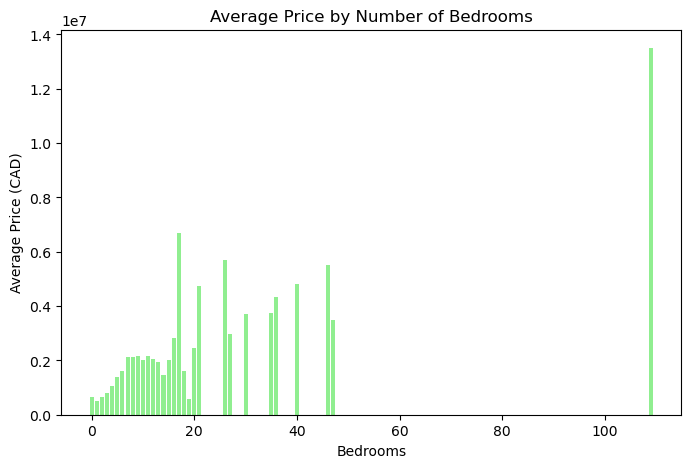

In [33]:
bed_avg = df.groupby('Number_Beds')['Price'].mean().reset_index()
fig, ax = plt.subplots(figsize=(8,5))
ax.bar(bed_avg['Number_Beds'], bed_avg['Price'], color='lightgreen')
ax.set_title('Average Price by Number of Bedrooms')
ax.set_xlabel('Bedrooms')
ax.set_ylabel('Average Price (CAD)')
plt.show()

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35768 entries, 0 to 35767
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   City                  35768 non-null  object 
 1   Price                 35768 non-null  float64
 2   Address               35768 non-null  object 
 3   Number_Beds           35768 non-null  int64  
 4   Number_Baths          35768 non-null  int64  
 5   Province              35768 non-null  object 
 6   Population            35768 non-null  int64  
 7   Latitude              35768 non-null  float64
 8   Longitude             35768 non-null  float64
 9   Median_Family_Income  35768 non-null  float64
dtypes: float64(4), int64(3), object(3)
memory usage: 2.7+ MB


In [35]:
df.isnull().sum()

City                    0
Price                   0
Address                 0
Number_Beds             0
Number_Baths            0
Province                0
Population              0
Latitude                0
Longitude               0
Median_Family_Income    0
dtype: int64

In [36]:
df.duplicated().sum()

2516

In [37]:
# Drop the duplicate rows in the data
df.drop_duplicates(inplace = True)

In [38]:
df.describe()

,Price,Number_Beds,Number_Baths,Population,Latitude,Longitude,Median_Family_Income
count,3.325200e+04,33252.000000,33252.000000,3.325200e+04,33252.000000,33252.000000,33252.000000
mean,9.780968e+05,3.294388,2.555786,6.592545e+05,47.272550,-98.419248,89898.860911
std,1.041994e+06,1.747455,1.385224,1.148804e+06,3.307946,22.728483,12351.789458
min,2.150000e+04,0.000000,0.000000,6.338200e+04,42.283300,-123.936400,62400.000000
25%,4.950000e+05,2.000000,2.000000,1.091670e+05,43.866700,-122.600000,82000.000000
50%,7.249000e+05,3.000000,2.000000,2.424600e+05,48.428300,-104.606700,89000.000000
75%,1.124900e+06,4.000000,3.000000,7.295600e+05,49.266700,-79.676900,97000.000000
max,3.700000e+07,109.000000,59.000000,5.647656e+06,53.916900,63.100500,133000.000000


In [39]:
# Drop the 'Address', 'Latitude' and 'Longitude' columns. I will not use this column to make predictions.
df.drop(['Address','Latitude','Longitude'],axis = 1, inplace = True)

In [42]:
# Drop non-snsical rows from our data. E.g., dropping the row where number of beds is more than 20 and number of bathrooms is more than 10
beds_more_than_20_idx = df[df['Number_Beds'] > 20].index
df.drop(beds_more_than_20_idx,inplace = True)

baths_more_than_10_idx = df[df['Number_Baths'] > 10].index
df.drop(baths_more_than_10_idx, inplace = True)

In [43]:
# There are some data points where the number of bedrooms and number of bathrooms are both 0. These data points do not make sense to me.
# I will drop these daata points
zero_rooms_idx = df[(df['Number_Baths'] == 0) & (df['Number_Beds'] == 0)].index
df.drop(zero_rooms_idx, inplace = True)


In [44]:
# Replacing the value of the number of bedrooms with more than 4 bedrooms to '>4'
greater_than_4_beds_idx = df[df['Number_Beds'] > 4].index
df.loc[greater_than_4_beds_idx,'Number_Beds'] = '>4'
df['Number_Beds'] = df['Number_Beds'].apply(str)

/var/folders/0s/s2qqdkfs7_b9yv8pvrv2djp00000gn/T/ipykernel_2891/1930889296.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '>4' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[greater_than_4_beds_idx,'Number_Beds'] = '>4'


In [45]:
#Replacing the value of the number of bathrooms with more than 3 bathrooms to '>3'
greater_than_3_baths_idx = df[df['Number_Baths'] > 3].index
df.loc[greater_than_3_baths_idx,'Number_Baths'] = '>3'
df['Number_Baths'] = df['Number_Baths'].apply(str)

/var/folders/0s/s2qqdkfs7_b9yv8pvrv2djp00000gn/T/ipykernel_2891/2304820226.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '>3' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[greater_than_3_baths_idx,'Number_Baths'] = '>3'


In [46]:
df

,City,Price,Number_Beds,Number_Baths,Province,Population,Median_Family_Income
0,Toronto,779900.0,3,2,Ontario,5647656,97000.0
1,Toronto,799999.0,3,1,Ontario,5647656,97000.0
2,Toronto,799900.0,2,2,Ontario,5647656,97000.0
3,Toronto,1200000.0,4,2,Ontario,5647656,97000.0
4,Toronto,668800.0,1,1,Ontario,5647656,97000.0
...,...,...,...,...,...,...,...
35763,Halifax,439900.0,2,2,Nova Scotia,431479,86753.0
35764,Halifax,6990000.0,>4,>3,Nova Scotia,431479,86753.0
35765,Halifax,419900.0,2,2,Nova Scotia,431479,86753.0
35766,Halifax,949900.0,3,1,Nova Scotia,431479,86753.0


In [47]:
print(f'The size of the data after dropping rows and columns of the data is :- Number of rows: {df.shape[0]} | Number of columns: {df.shape[1]}')

The size of the data after dropping rows and columns of the data is :- Number of rows: 32757 | Number of columns: 7


In [48]:
# Replacing the long province names with shorter names. E.g., Ontario -> ON | Alberta -> AB
# Replacing this will help in data visualization
def short_province(df):
    long_name_list = ['Ontario','British Columbia', 'Alberta', 'Saskatchewan', 'Newfoundland and Labrador', 'New Brunswick', 'Quebec', 'Manitoba','Nova Scotia']
    short_name_list = ['ON', 'BC', 'AB', 'SK', 'NL', 'NB', 'QC', 'MB', 'NS']
    for i in range(len(long_name_list)):
        df.replace(to_replace = long_name_list[i],value = short_name_list[i],inplace = True)
        
short_province(df)

/var/folders/0s/s2qqdkfs7_b9yv8pvrv2djp00000gn/T/ipykernel_2891/4174366084.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = 'Province', data = df, palette = 'Blues')


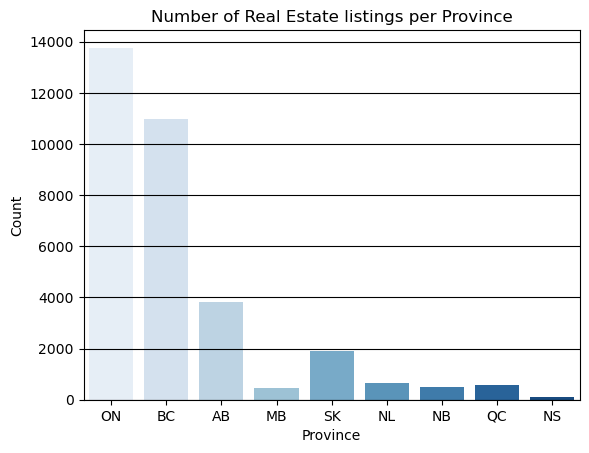

In [49]:
sns.countplot(x = 'Province', data = df, palette = 'Blues')
plt.grid(axis = 'y',color = 'black')
plt.ylabel('Count')
plt.title("Number of Real Estate listings per Province")
plt.show()

Text(0, 0.5, 'Count')

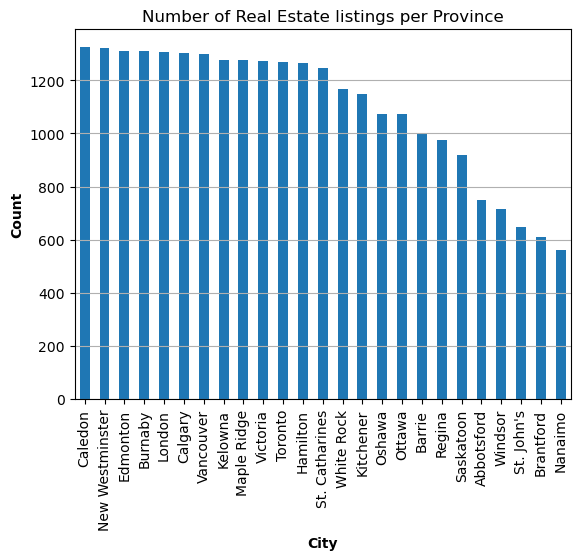

In [50]:
df['City'].value_counts().head(25).plot(kind = 'bar')
plt.grid(axis = 'y')
plt.title("Number of Real Estate listings per Province")
plt.xlabel("City",fontweight = 'bold')
plt.ylabel("Count", fontweight = 'bold')

Text(0.5, 1.0, 'Histogram & KDE of Price')

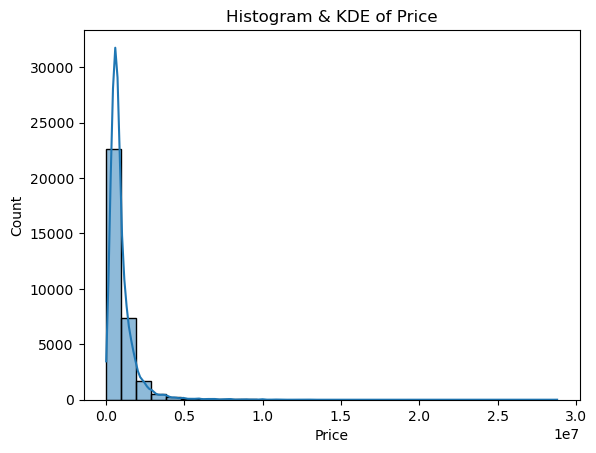

In [51]:
sns.histplot(df['Price'],kde = True, bins = 30)
plt.title('Histogram & KDE of Price')

Text(0.5, 1.0, 'Histogram & KDE of Median Family Income')

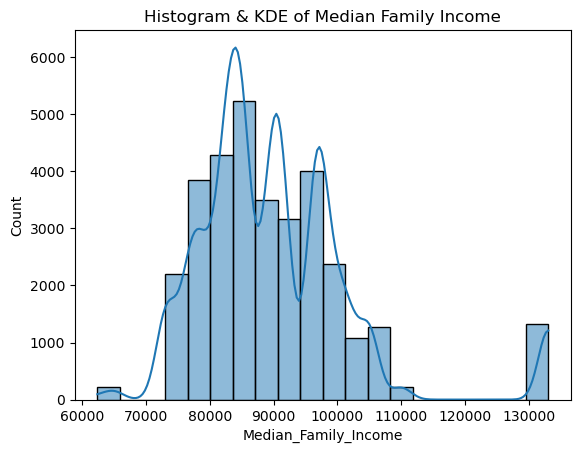

In [52]:
sns.histplot(df['Median_Family_Income'],kde = True, bins = 20)
plt.title('Histogram & KDE of Median Family Income')

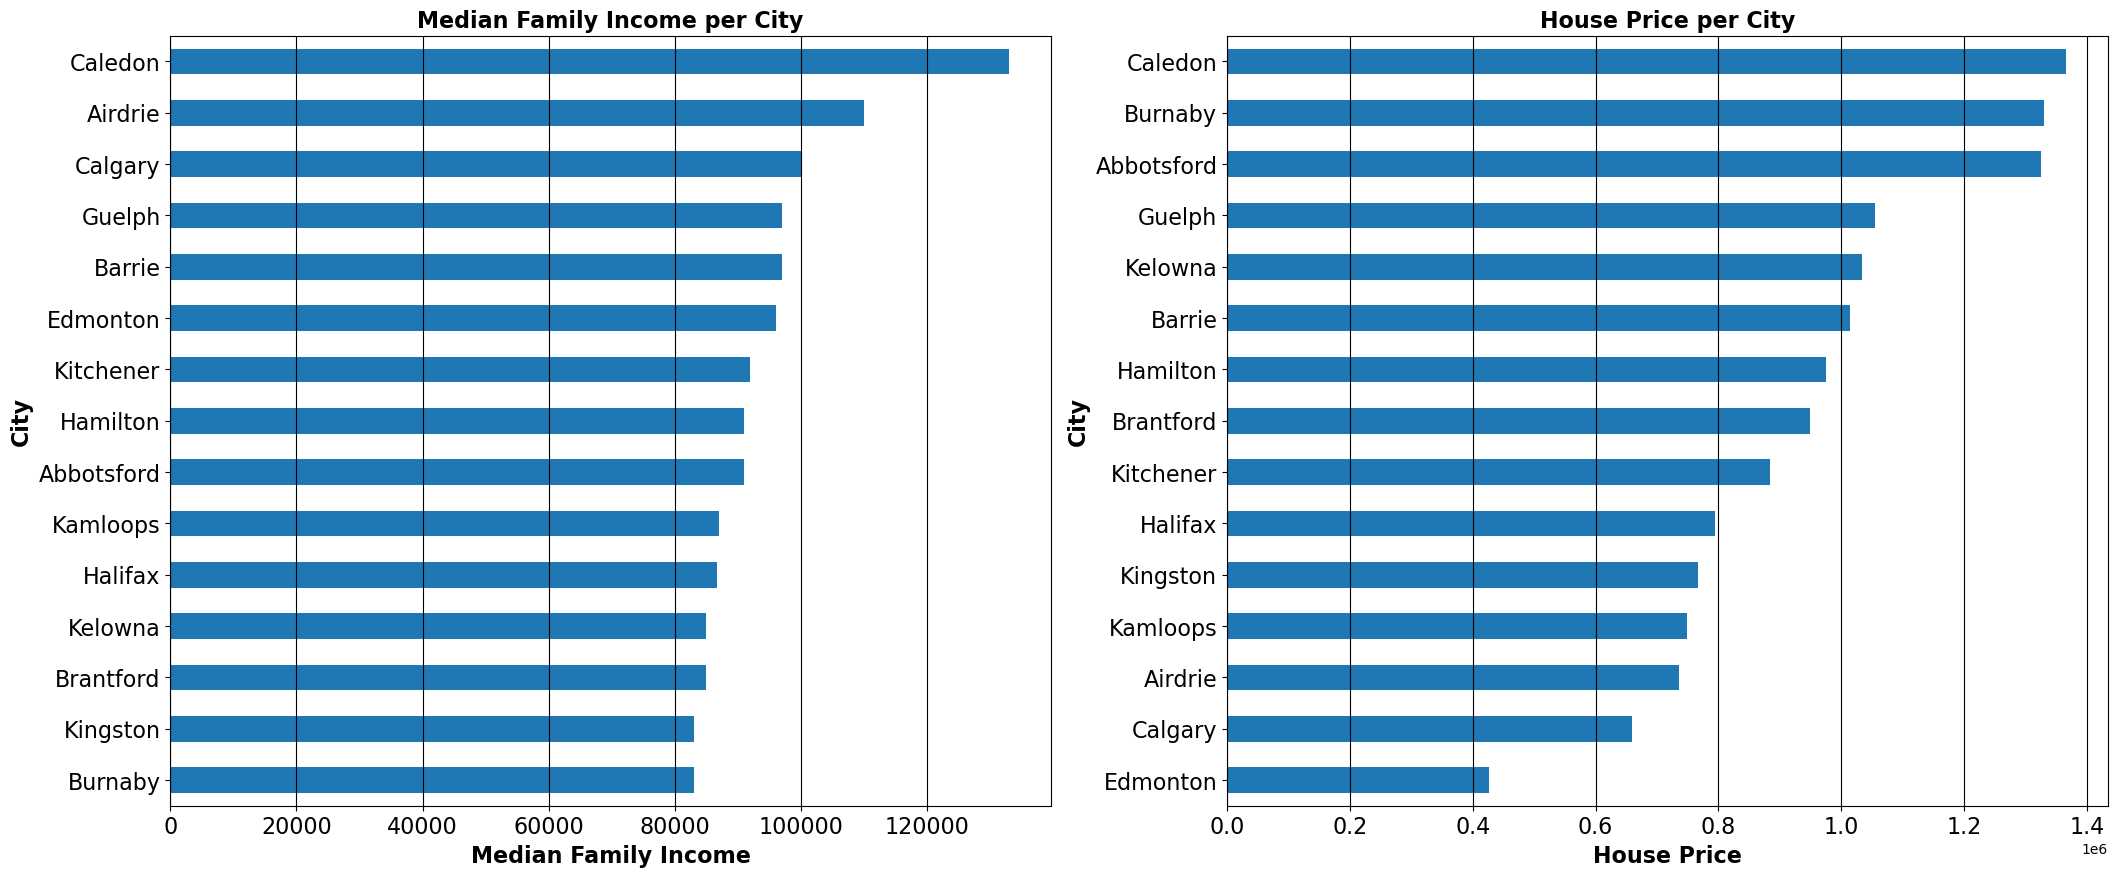

In [53]:
fig, ax = plt.subplots(nrows=1, ncols=2,figsize = (25,10))

df.groupby('City')['Median_Family_Income'].mean().head(15).sort_values().plot(kind = 'barh',ax = ax[0])
ax[0].set_ylabel('City',fontweight = 'bold', fontsize = 16)
ax[0].set_xlabel('Median Family Income', fontweight = 'bold', fontsize = 16)
ax[0].set_title('Median Family Income per City', fontweight = 'bold', fontsize = 16)
ax[0].grid(axis = 'x',color = 'black')
ax[0].tick_params(axis='both', labelsize=16, rotation = 0)

df.groupby('City')['Price'].mean().head(15).sort_values().plot(kind = 'barh', ax = ax[1])
ax[1].set_ylabel('City',fontweight = 'bold', fontsize = 16)
ax[1].set_xlabel('House Price', fontweight = 'bold', fontsize = 16)
ax[1].set_title('House Price per City', fontweight = 'bold', fontsize = 16)
ax[1].grid(axis = 'x',color = 'black')
ax[1].tick_params(axis='both', labelsize=16, rotation = 0)

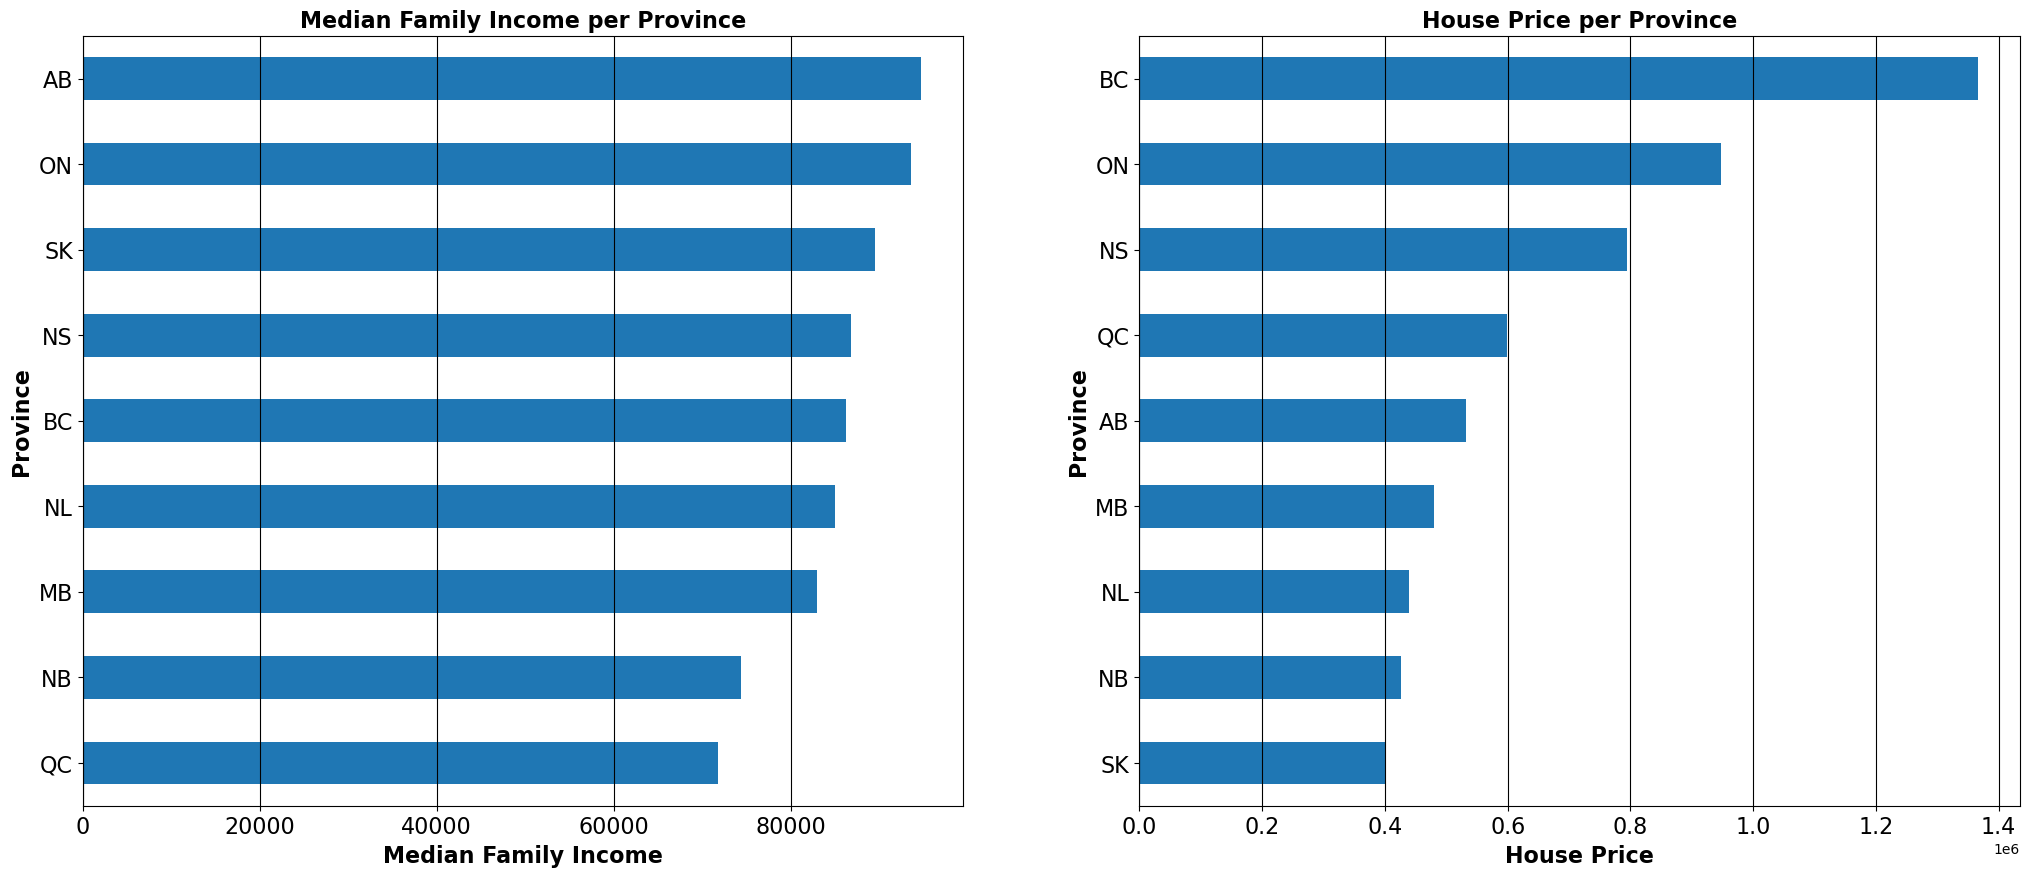

In [55]:
fig, ax = plt.subplots(nrows=1, ncols=2,figsize = (25,10))

df.groupby('Province')['Median_Family_Income'].mean().sort_values().plot(kind = 'barh',ax = ax[0])
ax[0].set_ylabel('Province',fontweight = 'bold', fontsize = 16)
ax[0].set_xlabel('Median Family Income', fontweight = 'bold', fontsize = 16)
ax[0].set_title('Median Family Income per Province', fontweight = 'bold', fontsize = 16)
ax[0].grid(axis = 'x',color = 'black')
ax[0].tick_params(axis='both', labelsize=16, rotation = 0)

df.groupby('Province')['Price'].mean().sort_values().plot(kind = 'barh', ax = ax[1])
ax[1].set_ylabel('Province',fontweight = 'bold', fontsize = 16)
ax[1].set_xlabel('House Price', fontweight = 'bold', fontsize = 16)
ax[1].set_title('House Price per Province', fontweight = 'bold', fontsize = 16)
ax[1].grid(axis = 'x',color = 'black')
ax[1].tick_params(axis='both', labelsize=16, rotation = 0)

Text(0, 0.5, 'Price')

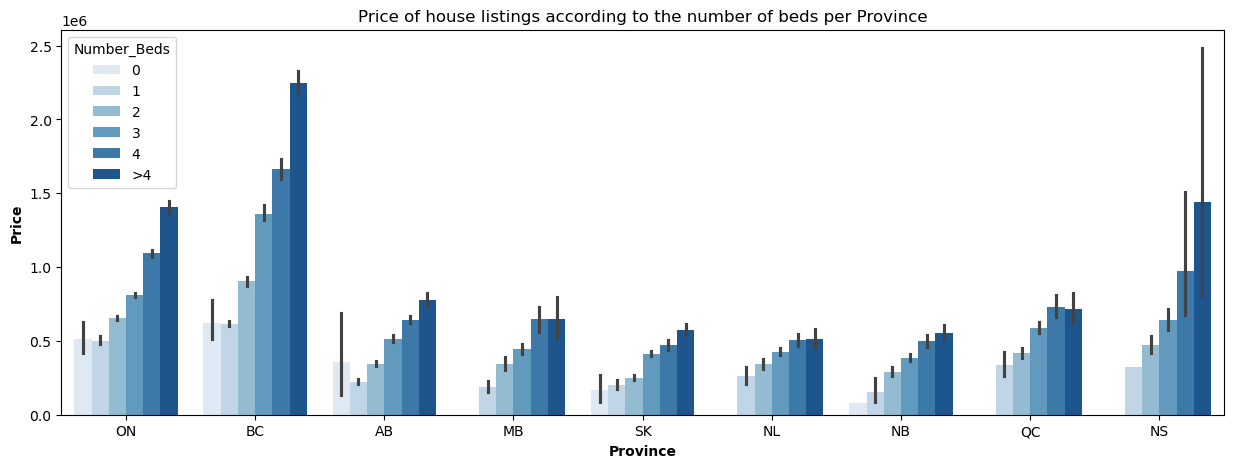

In [56]:
plt.figure(figsize = (15,5))
hue_order = ['0','1','2','3','4','>4']
sns.barplot(data = df,x = 'Province',y = 'Price', hue = 'Number_Beds', hue_order = hue_order, palette = "Blues")
plt.title("Price of house listings according to the number of beds per Province")
plt.xlabel('Province',fontweight = 'bold')
plt.ylabel('Price',fontweight = 'bold')

Text(0, 0.5, 'Price')

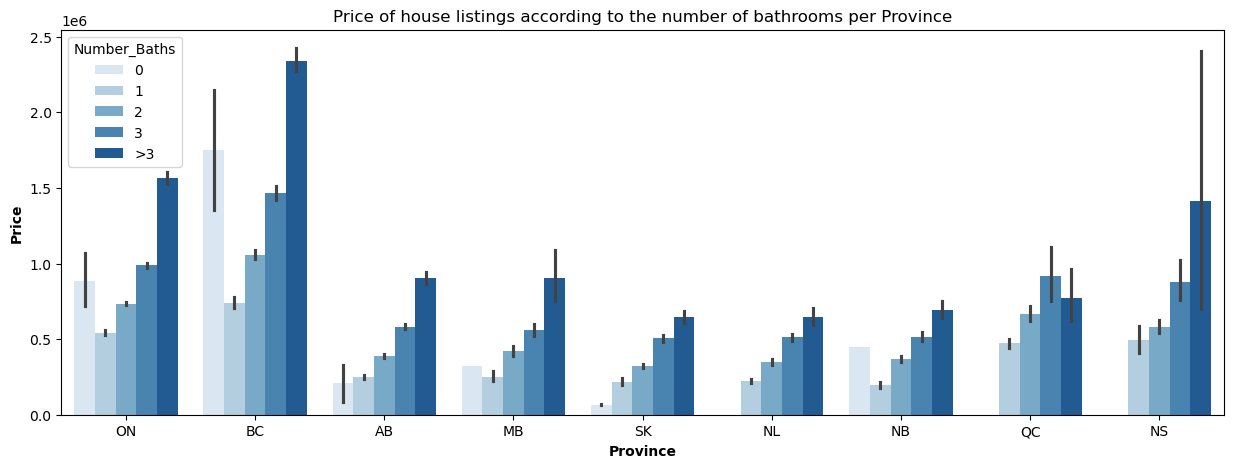

In [57]:
plt.figure(figsize = (15,5))
hue_order = ['0','1','2','3','>3']
sns.barplot(data = df,x = 'Province',y = 'Price', hue = 'Number_Baths', hue_order = hue_order, palette = "Blues")
plt.title("Price of house listings according to the number of bathrooms per Province")
plt.xlabel('Province',fontweight = 'bold')
plt.ylabel('Price',fontweight = 'bold')

In [58]:
from sklearn.model_selection import train_test_split

y = df['Price']
X = df.drop('Price',axis = 1)
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 7)

print(f'X_train size: {X_train.shape} | y_train size: {y_train.shape} | X_test size: {X_test.shape} | y_test size: {y_test.shape}')

X_train size: (26205, 6) | y_train size: (26205,) | X_test size: (6552, 6) | y_test size: (6552,)


In [59]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OrdinalEncoder

ohe = OneHotEncoder(drop = 'first', sparse_output = False)
ohe_features = ['City','Province']
oe = OrdinalEncoder()
oe_features = ['Number_Beds','Number_Baths']
std = StandardScaler()
num_features = ['Population','Median_Family_Income']

ct = ColumnTransformer(transformers=[('ohe', ohe, ohe_features ),
                                     ('oe', oe , oe_features),
                                     ('scaler', std, num_features)
                                    ]
                       ,remainder='passthrough')


X_train_transformed = ct.fit_transform(X_train)
X_test_transformed = ct.transform(X_test)

In [60]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train_transformed,y_train)
y_pred = lr.predict(X_test_transformed)

In [61]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R² Score:", r2)

Mean Squared Error: 511527589658.708
R² Score: 0.3845094563021204


In [62]:
feature_names = ct.get_feature_names_out()
for name, coef in zip(feature_names, lr.coef_):
    print(f"{name}: {coef}")

ohe__City_Airdrie: -110296.07260585077
ohe__City_Barrie: 111545.13934046065
ohe__City_Brantford: 59822.381447721855
ohe__City_Burnaby: 336623.65266730066
ohe__City_Caledon: 182255.5443370514
ohe__City_Calgary: -97130.24510796016
ohe__City_Edmonton: -216332.61006210418
ohe__City_Guelph: 220579.4893004892
ohe__City_Halifax: 133052.89013020205
ohe__City_Hamilton: 63001.402750371395
ohe__City_Kamloops: -504614.01603567717
ohe__City_Kelowna: -192327.66522008876
ohe__City_Kingston: -24438.56306946138
ohe__City_Kitchener: 65540.76958182383
ohe__City_Lethbridge: -112988.7393864275
ohe__City_London: -98974.47649874259
ohe__City_Maple Ridge: 139815.61507843086
ohe__City_Medicine Hat: -131309.11927161887
ohe__City_Moncton: -8929.337205872987
ohe__City_Montreal: -72815.46930332843
ohe__City_Nanaimo: -290958.44521530636
ohe__City_New Westminster: 126968.88245891166
ohe__City_Oshawa: -34905.41935249686
ohe__City_Ottawa: -60132.27330275702
ohe__City_Peterborough: 31353.854559296313
ohe__City_Prince G

Text(0, 0.5, 'Feature')

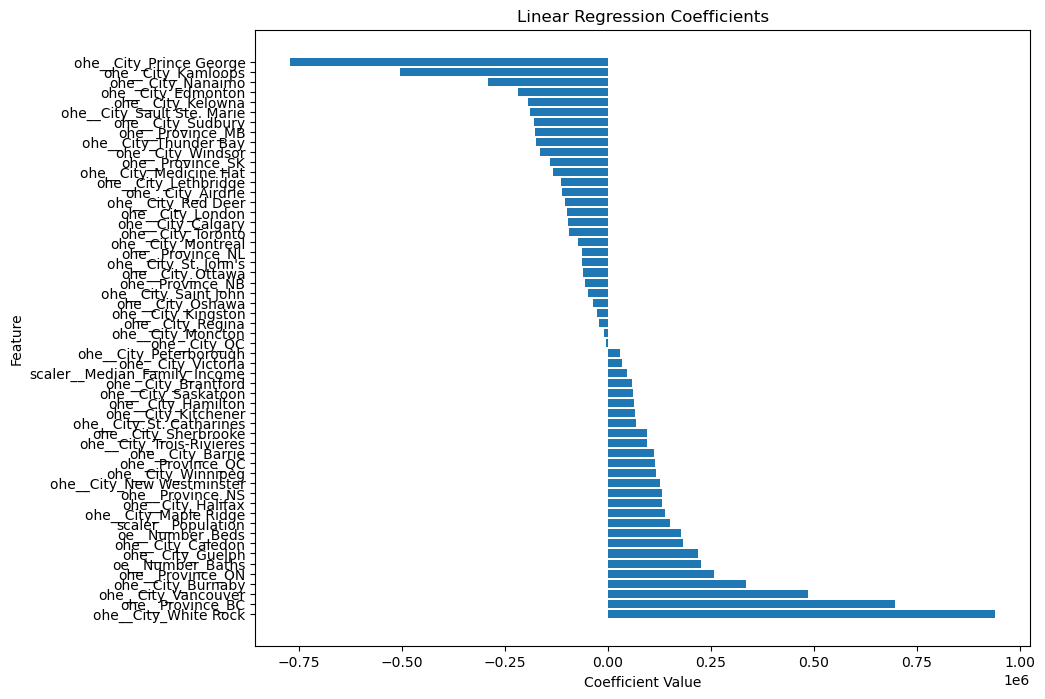

In [63]:
feature_names = ct.get_feature_names_out()
coefs = lr.coef_

coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefs})
coef_df = coef_df.sort_values('Coefficient', ascending=False)

plt.figure(figsize=(10,8))
plt.barh(coef_df['Feature'], coef_df['Coefficient'])
plt.title('Linear Regression Coefficients')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')